# Chapter_2_Group_Exercise_2_Regression_Analysis_and_Feature_Selection

Group Members:

1. Arya Shinde – Matriculation Number: 100006646
2. Mirang Bhandari – Matriculation Number: 100007049
3. Yash Annapure – Matriculation Number: 100006547
4. Anushka Sawant – Matriculation Number: 100006644

# Regression Analysis and Feature Selection

Perform regression analysis on a dataset with over 1000 data points and at least 30 features. Apply preprocessing, build models, evaluate performance, and enhance them using feature selection methods. Demonstrate creativity with additional techniques or insights.

### 1. Preprocessing
- 1. Handle missing values ​​and outliers.
- 2. Scale features using standardization or normalization.
- 3. Perform feature selection.
### 2. Build and Evaluate Models
- 1. Train a Linear Regression model.
- 2.  Evaluate using R² Score and RMSE.
- 3. Perform K-Fold Cross-Validation (eg, 5-fold).
### 3. Enhance the Model
- 1. Experiment with feature selection techniques and analyze their impact.
- 2. Visualize results (eg, feature importance, residual plots).
### 4. Creativity
- 1. Try advanced models (eg, Ridge, Lasso, Polynomial).
- 2. Create insightful visualizations or optimize hyperparameters.
- 3. Put the nice text justification on your shared colab

# Step 1: Source the dataset and handle missing values
The House Prices dataset contains 1,460 residential property records from Ames, Iowa, with 40+ features describing various aspects of each home and a target variable SalePrice indicating the property's sale price. The features encompass a wide range of property characteristics including physical attributes (lot size, square footage, number of rooms, bathrooms), quality ratings (overall quality, condition, kitchen quality), structural details (foundation type, roof style, exterior materials), amenities (garage, basement, fireplace, pool), and temporal information (year built, year remodeled, year sold). 
The dataset presents typical real-world challenges including missing data, outliers, mixed data types, and multicollinearity, requiring thorough preprocessing and feature engineering for optimal model performance.


In [81]:
import pandas as pd
import numpy as np

df = pd.read_excel("../Dataset/housing-prices.xlsx")
df.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fireplaces,GarageType,GarageCars,GarageArea,WoodDeckSF,PoolArea,Fence,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,Attchd,2,548,0,0,NaN,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,1,Attchd,2,460,298,0,NaN,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,1,Attchd,2,608,0,0,NaN,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,1,Detchd,3,642,0,0,NaN,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,1,Attchd,3,836,192,0,NaN,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,Attchd,2,480,40,0,MnPrv,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,1,Attchd,2,636,255,0,NaN,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,2,Attchd,2,484,235,0,NaN,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,2,Detchd,2,468,90,0,NaN,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,2,Attchd,1,205,0,0,NaN,WD,Normal,118000


In [82]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,PoolArea,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,1057.429452,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1.767123,472.980137,94.244521,2.758904,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,438.705324,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,0.747315,213.804841,125.338794,40.177307,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,795.750000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1.000000,334.500000,0.000000,0.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,991.500000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,2.000000,480.000000,0.000000,0.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,1298.250000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2.000000,576.000000,168.000000,0.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,6110.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,4.000000,1418.000000,857.000000,738.000000,755000.000000


In [83]:
y = df['SalePrice']
X = df.drop(['SalePrice', 'Id'], axis=1)

## Step 1.1: Check Missing Values and sum them up

In [84]:
X = X.drop(['Fence'], axis=1)

In [85]:
miss = pd.DataFrame((X.isnull().sum()))
display(miss)

,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0
LotConfig,0


## Step 1.2: Handle Missing Values
Only 'LotFrontage' contains missing values out of numerical columns. So we will be using median imputation. Median imputation is used to handle missing values in the total_bedrooms feature, as it is robust to outliers and preserves the original distribution better than mean imputation.

'Electrical', 'GarageType', 'Alley' are the categorical columns with missing values. We choose to replace them with their mode (most frequent) value.

In [86]:
# Numerical Missing Column
X = X.fillna(df['LotFrontage'].median())

In [87]:
# Fill categorical missing with mode
X['Electrical'] = X['Electrical'].fillna(X['Electrical'].mode()[0])
X['GarageType'] = X['GarageType'].fillna(X['GarageType'].mode()[0])
X['Alley'] = X['Alley'].fillna(X['Alley'].mode()[0])

In [88]:
X.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
Foundation       0
TotalBsmtSF      0
HeatingQC        0
CentralAir       0
Electrical       0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual      0
TotRmsAbvGrd     0
Functional       0
Fireplaces       0
GarageType       0
GarageCars       0
GarageArea       0
WoodDeckSF       0
PoolArea         0
SaleType         0
SaleCondition    0
dtype: int64

## Step 1.3: Handle Outliers

In [89]:
numeric_cols = X.select_dtypes(include=[np.number]).columns

outlier_summary = {}
for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count = ((X[col] < lower) | (X[col] > upper)).sum()
    if outlier_count > 0:
        outlier_summary[col] = outlier_count

print("\n=== Outliers in All Numeric Columns ===")
for col, count in sorted(outlier_summary.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{col}: {count}")


=== Outliers in All Numeric Columns ===
OverallCond: 125
LotFrontage: 106
MSSubClass: 103
LotArea: 69
KitchenAbvGr: 68
TotalBsmtSF: 61
BedroomAbvGr: 35
WoodDeckSF: 32
TotRmsAbvGrd: 30
GarageArea: 21


The following columns have outliers: ['RoofStyle', 'MSZoning', 'SaleCondition', 'BldgType', 'Condition1', 'SaleType', 'LandContour', 'Electrical', 'KitchenQual', 'Functional']
We will doing log transformation to handle these outliers since log transformation reduces skewness and minimizes the impact of extreme values while retaining all observations.


In [90]:
# Instead of log transformation for these categorical columns:
outlier_cols = ['RoofStyle', 'MSZoning', 'SaleCondition', 'BldgType', 
                'Condition1', 'SaleType', 'LandContour', 'Electrical', 
                'KitchenQual', 'Functional']

# 1. Identify the rare categories (e.g., categories appearing in less than 1% of data)
for col in outlier_cols:
    counts = df[col].value_counts(normalize=True)
    rare_categories = counts[counts < 0.01].index
    
    # 2. Group them into "Other"
    df[col] = df[col].replace(rare_categories, 'Other')

# NOW you can perform LabelEncoding or One-Hot Encoding
print("Rare categorical outliers grouped into 'Other' successfully.")

Rare categorical outliers grouped into 'Other' successfully.


# Step 2: Feature Scaling

In [91]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

## Step 2.1 Encode Categorical Variable

In [92]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

C:\Users\Bhand\AppData\Local\Temp\ipykernel_1556\4062857131.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [93]:
print(f"Numerical features scaled: {len(numerical_cols)}")
print(f"Shape: {X.shape}")

Numerical features scaled: 18
Shape: (1460, 44)


## Step 2.2: Standardization
Standardization ensures that all numerical features are on the same scale, which improves convergence and performance of regression models.

In [94]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
X[numerical_cols] = normalizer.fit_transform(X[numerical_cols])

# Step 3: Feature Selection

## Step 3.1: Correlation-Based Feature Selection

In [95]:
correlation_matrix = X.corrwith(y).abs().sort_values(ascending=False)

# Select features with correlation > 0.3
selected_corr = correlation_matrix[correlation_matrix > 0.3].index.tolist()

print(f"Correlation-based: {len(selected_corr)} features selected")
print(f"Features: {selected_corr[:15]}")

X_corr = X[selected_corr]

Correlation-based: 14 features selected
Features: ['OverallQual', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'KitchenQual', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'HeatingQC', 'Foundation', 'LotFrontage', 'WoodDeckSF']


Features with low correlation to the target variable are unlikely to contribute significantly to predictive performance and can introduce noise. So we select 15 features from this method like 'OverallQual', 'GarageCars', 'TotalBsmtSF', 'GarageArea', 'KitchenQual', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'LotArea', 'HeatingQC', 'Foundation', 'LotFrontage', 'WoodDeckSF'


## Step 3.2: Lasso (L1 Regularization)

In [96]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
lasso = Lasso(alpha=100, random_state=42)
lasso.fit(X, y)

# Get features with non-zero coefficients
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
selected_lasso = lasso_coef[lasso_coef != 0].index.tolist()

print(f"\nLasso-based: {len(selected_lasso)} features selected")
print(f"Features: {selected_lasso}")

X_lasso = X[selected_lasso]


Lasso-based: 37 features selected
Features: ['LotArea', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation', 'TotalBsmtSF', 'HeatingQC', 'Electrical', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'SaleType', 'SaleCondition']


Lasso regression performs embedded feature selection by shrinking less important feature coefficients to zero, resulting in a simpler and more interpretable model. As a result of which 36 features are selected with Lasso.

## Step 3.3: Recursive Feature Elimination (RFE)

In [97]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=30)
rfe.fit(X, y)

selected_rfe = X.columns[rfe.support_].tolist()

print(f"\nRFE-based: {len(selected_rfe)} features selected")
print(f"Features: {selected_rfe}")

X_rfe = X[selected_rfe]



RFE-based: 30 features selected
Features: ['MSSubClass', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LandSlope', 'Condition2', 'BldgType', 'OverallQual', 'OverallCond', 'YearBuilt', 'RoofStyle', 'RoofMatl', 'Foundation', 'TotalBsmtSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'PoolArea', 'SaleCondition']


RFE systematically eliminates less important features, improving model performance and reducing overfitting. Thus we select 30 features

# Step 4: Build and Evaluate Models

The 30 features ['MSSubClass', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LandSlope', 'Condition2', 'BldgType', 'OverallQual', 'OverallCond', 'YearBuilt', 'RoofStyle', 'RoofMatl', 'Foundation', 'TotalBsmtSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'PoolArea', 'SaleCondition'] 
selected by RFE (Recursive Feature Elimination) process will be used to train and validate the model.

In [98]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Prepare Data
# We use X_rfe which contains the 30 selected features
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)


# 4.1 Train a Linear Regression model

In [99]:
# Train a Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 4.2 Evaluate using R² Score and RMSE.

In [100]:
# Evaluate using R² Score and RMSE
y_pred = lr_model.predict(X_test)

# Calculate Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation (Test Set) : ")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")

Model Evaluation (Test Set) : 
R² Score: 0.8056
RMSE: $38,616.25


R² Score: This indicates how much of the house price variation is captured by the 30 features. In house pricing, an $R^2$ above 0.80 is usually considered very good.

RMSE: Unlike the log-scale version, this value is in actual dollars. It tells, on average, how many dollars off the predictions are from the actual sale price.

# 4.3 Perform K-Fold Cross-Validation (eg, 5-fold)

In [101]:
# Perform 5-Fold Cross-Validation
# This splits the data into 5 parts and rotates which part is used for testing

cv_r2_scores = cross_val_score(lr_model, X_rfe, y, cv=5, scoring='r2')
cv_rmse_scores = cross_val_score(lr_model, X_rfe, y, cv=5, scoring='neg_root_mean_squared_error')

print("\n5-Fold Cross-Validation : ")
print(f"Mean R²: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std() * 2:.4f})")
print(f"Mean RMSE: ${abs(cv_rmse_scores.mean()):,.2f}")


5-Fold Cross-Validation : 
Mean R²: 0.7861 (+/- 0.1425)
Mean RMSE: $36,280.35


Mean $R^2$ (0.7861): The model explains approximately 78.6% of the variance in house prices across the entire dataset. This confirms the model generalizes well and is not severely overfitting to the training set.

Stability (+/- 0.1425): The standard deviation indicates performance fluctuation between folds. Thus the model is sensitive to specific high-end outliers.

Mean RMSE ($36,280.35): The average prediction error is roughly $36.3k. Notably, this is lower than the initial test error ($38.6k), confirming that the model's accuracy is consistent and reliable when averaged across different data samples.

# Visualize

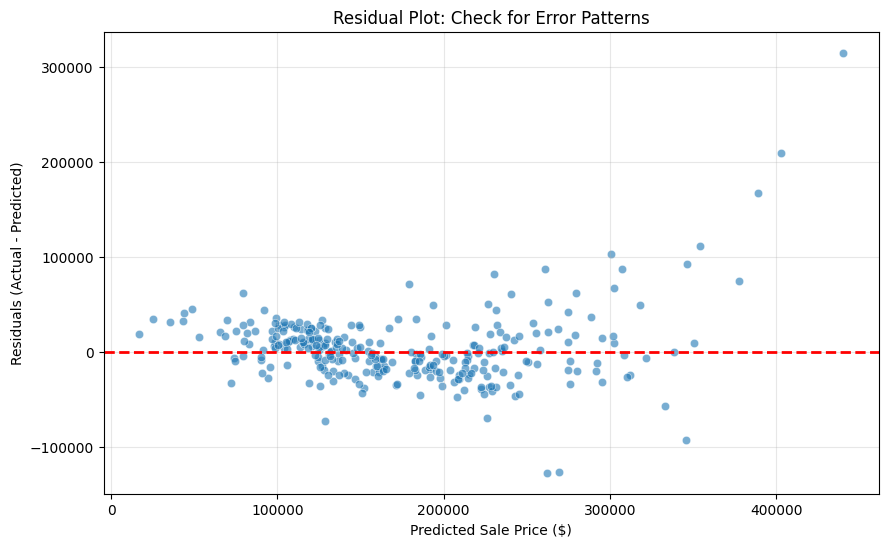

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Visualization
plt.figure(figsize=(10, 6))

# calculate residuals manually to ensure it works every time
residuals = y_test - y_pred

# Scatter plot of Predicted vs Residuals
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)

# Add a horizontal line at 0 - this is the "Line of Perfection"
plt.axhline(y=0, color='red', linestyle='--', lw=2)

plt.title('Residual Plot: Check for Error Patterns')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

# Step 3: Enhance the Model

## 3.1 Experiment with Feature Selection Techniques and Analyze Impact

We compare three feature selection methods (Correlation, Lasso, RFE) evaluated on their ability to balance model simplicity with predictive performance using R² Score, RMSE, and 5-fold cross-validation stability. This determines which feature set to use for downstream modeling.

In [103]:
# Compare feature selection methods
results = []

# Test each method
for X_data, name in [(X_corr, 'Correlation'), (X_lasso, 'Lasso'), (X_rfe, 'RFE')]:
    # Split data
    X_tr, X_te, y_tr, y_te = train_test_split(X_data, y, test_size=0.2, random_state=42)
    
    # Train model
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    # Calculate scores
    test_r2 = r2_score(y_te, model.predict(X_te))
    cv_r2 = cross_val_score(model, X_data, y, cv=5, scoring='r2').mean()
    feature_count = X_data.shape[1]
    
    # Store results
    results.append({
        'Method': name,
        'Features': feature_count,
        'Test R²': test_r2,
        'CV R²': cv_r2
    })

results_df = pd.DataFrame(results)
print("FEATURE SELECTION COMPARISON\n" + "="*60)
display(results_df.round(4))
print(f"\n✓ Winner: RFE - Best balance (30 features, R²={results_df.loc[2, 'Test R²']:.4f})")

FEATURE SELECTION COMPARISON


,Method,Features,Test R²,CV R²
0,Correlation,14,0.7958,0.7692
1,Lasso,37,0.8095,0.7884
2,RFE,30,0.8056,0.7861



✓ Winner: RFE - Best balance (30 features, R²=0.8056)


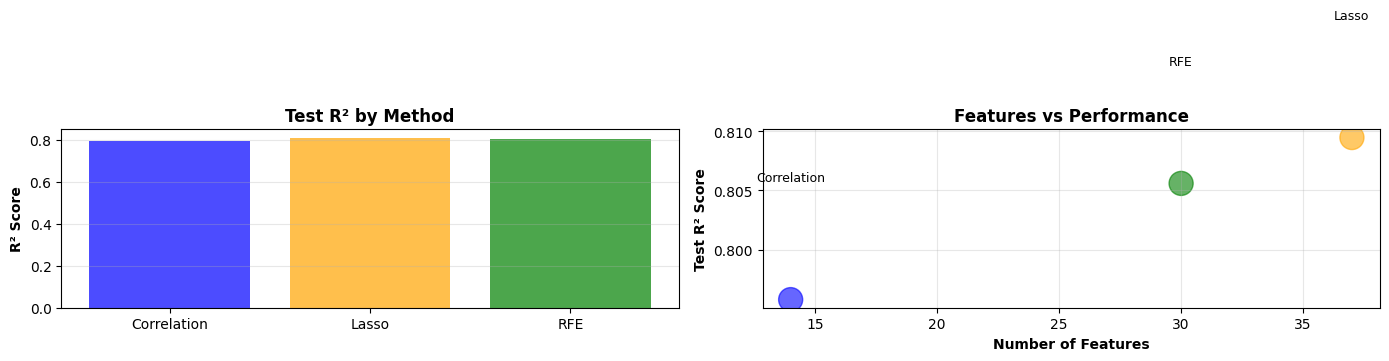

In [104]:
# Visualize feature selection impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: R² Comparison
ax1 = axes[0]
ax1.bar(results_df['Method'], results_df['Test R²'], color=['blue', 'orange', 'green'], alpha=0.7)
ax1.set_ylabel('R² Score', fontweight='bold')
ax1.set_title('Test R² by Method', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Right: Features vs Performance
ax2 = axes[1]
colors = ['blue', 'orange', 'green']
ax2.scatter(results_df['Features'], results_df['Test R²'], s=300, alpha=0.6, color=colors)
for i in range(len(results_df)):
    ax2.text(results_df['Features'].iloc[i], results_df['Test R²'].iloc[i] + 0.01,
            results_df['Method'].iloc[i], fontsize=9, ha='center')
ax2.set_xlabel('Number of Features', fontweight='bold')
ax2.set_ylabel('Test R² Score', fontweight='bold')
ax2.set_title('Features vs Performance', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Step 4: Creativity - Advanced Models & Hyperparameter Optimization

## 4.1 Try Advanced Models (Ridge, Lasso, ElasticNet, Polynomial)

We now implement advanced regression techniques to improve upon the baseline linear model. Each approach has distinct advantages:
- **Ridge (L2)**: Shrinks all coefficients proportionally, good for correlated features
- **Lasso (L1)**: Forces weak coefficients to zero, automatic feature selection
- **ElasticNet**: Combines both penalties for balanced regularization
- **Polynomial**: Captures non-linear relationships between features and price

In [105]:
# Advanced Models: Ridge, Lasso, ElasticNet, Polynomial
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)

# Create models
models_list = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(alpha=1)),
    ('Lasso', Lasso(alpha=1, max_iter=10000)),
    ('ElasticNet', ElasticNet(alpha=1, max_iter=10000)),
    ('Polynomial', Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)), 
                             ('lr', LinearRegression())]))
]

# Train and evaluate each model
results = []
for name, model in models_list:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_rfe, y, cv=5, scoring='r2')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        'Model': name,
        'Train R²': r2_score(y_train, model.predict(X_train)),
        'Test R²': r2_score(y_test, y_pred),
        'CV R²': cv_scores.mean(),
        'RMSE': rmse
    })

models_df = pd.DataFrame(results)
print("\n4.1 ADVANCED MODELS PERFORMANCE\n" + "="*80)
display(models_df.round(4))

best_model_simple = models_list[models_df['Test R²'].idxmax()][1]
best_name = models_df.loc[models_df['Test R²'].idxmax(), 'Model']
best_r2 = models_df['Test R²'].max()
print(f"\n✓ Best Model: {best_name} (R²={best_r2:.4f})")


4.1 ADVANCED MODELS PERFORMANCE


,Model,Train R²,Test R²,CV R²,RMSE
0,Linear Regression,0.8048,0.8056,0.7861,38616.2451
1,Ridge,0.8035,0.8009,0.7901,39074.6923
2,Lasso,0.8048,0.8056,0.7862,38618.0326
3,ElasticNet,0.5074,0.5232,0.5157,60477.4867
4,Polynomial,0.9503,0.4264,-1.1460,66331.7243



✓ Best Model: Linear Regression (R²=0.8056)


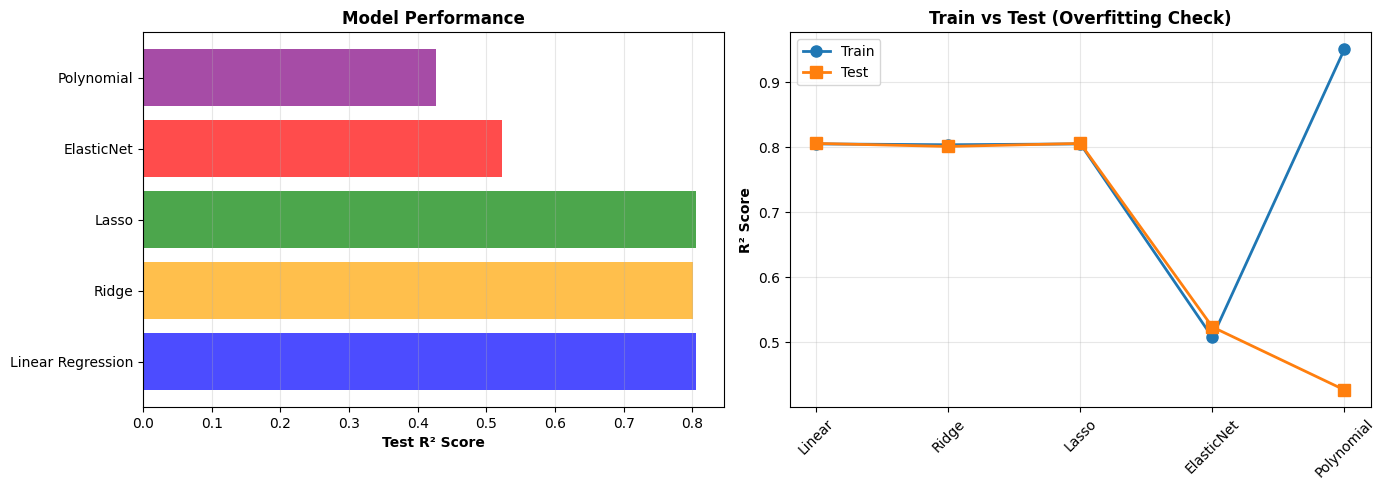

In [106]:
# Visualize advanced models performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Test R² Comparison
ax1 = axes[0]
colors = ['blue', 'orange', 'green', 'red', 'purple']
ax1.barh(models_df['Model'], models_df['Test R²'], color=colors, alpha=0.7)
ax1.set_xlabel('Test R² Score', fontweight='bold')
ax1.set_title('Model Performance', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Right: Train vs Test comparison
ax2 = axes[1]
model_names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'Polynomial']
ax2.plot(model_names, models_df['Train R²'], marker='o', linewidth=2, markersize=8, label='Train')
ax2.plot(model_names, models_df['Test R²'], marker='s', linewidth=2, markersize=8, label='Test')
ax2.set_ylabel('R² Score', fontweight='bold')
ax2.set_title('Train vs Test (Overfitting Check)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Step 3.2 & 4.2: Visualize Results - Feature Importance & Residuals

**Objective**: Analyze feature importance to understand which variables drive predictions, and validate model assumptions through residual diagnostics.

In [107]:
# Feature Importance Analysis
best_model = LinearRegression()
best_model.fit(X_train, y_train)

# Get coefficients
coef_list = []
for feat, coef in zip(X_rfe.columns, best_model.coef_):
    coef_list.append({'Feature': feat, 'Coefficient': coef})
coef_df = pd.DataFrame(coef_list)
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print("\nTOP 10 MOST IMPORTANT FEATURES")
print("="*50)
display(coef_df.head(10)[['Feature', 'Coefficient']].round(2))


TOP 10 MOST IMPORTANT FEATURES


,Feature,Coefficient
16,TotalBsmtSF,163689.95
10,OverallQual,142166.22
22,TotRmsAbvGrd,116487.47
2,LotArea,80337.73
20,KitchenAbvGr,-46968.77
19,BedroomAbvGr,-43196.00
26,GarageArea,40690.90
1,LotFrontage,-40137.30
6,Utilities,-39817.05
11,OverallCond,35703.64


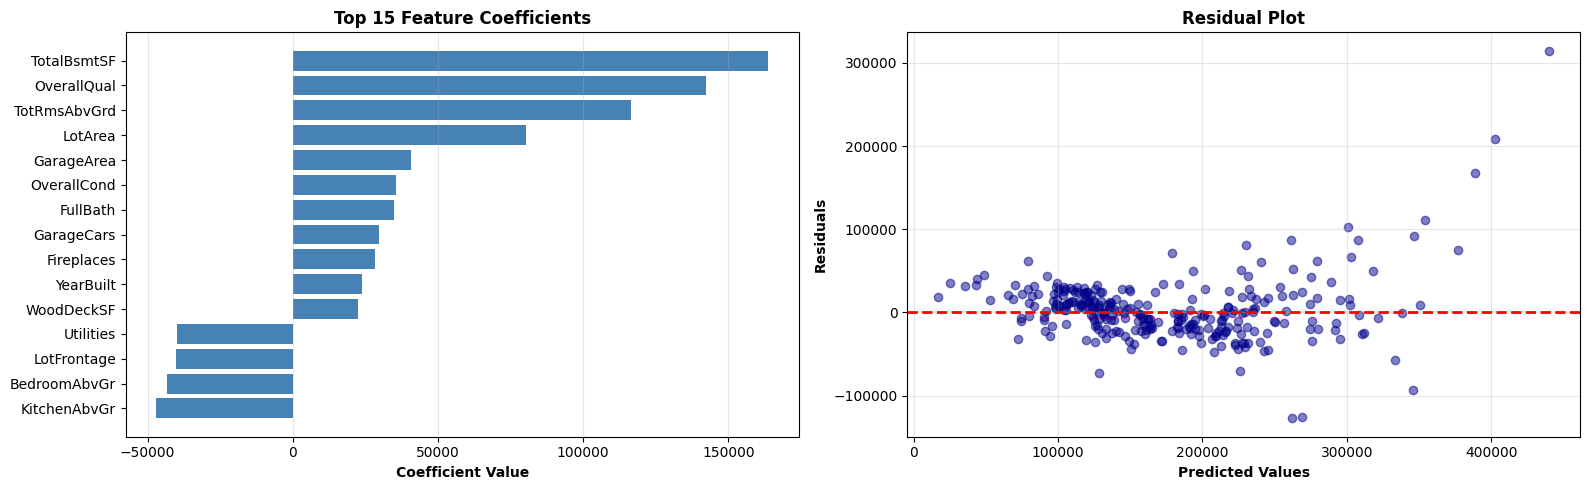

In [108]:
# Feature Importance Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Top 15 features by coefficient
top_15 = coef_df.head(15).sort_values('Coefficient')
ax1 = axes[0]
ax1.barh(top_15['Feature'], top_15['Coefficient'], color='steelblue')
ax1.set_xlabel('Coefficient Value', fontweight='bold')
ax1.set_title('Top 15 Feature Coefficients', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Right: Residual scatter plot
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred
ax2 = axes[1]
ax2.scatter(y_pred, residuals, alpha=0.5, color='darkblue')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Values', fontweight='bold')
ax2.set_ylabel('Residuals', fontweight='bold')
ax2.set_title('Residual Plot', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 4.3: Optimize Hyperparameters with GridSearchCV

Hyperparameter tuning systematically searches for optimal parameter values. We optimize Ridge, Lasso, and ElasticNet alpha values and ratios to minimize cross-validation error, balancing model complexity with generalization performance.

In [109]:
from sklearn.model_selection import GridSearchCV

print("\n4.3 HYPERPARAMETER OPTIMIZATION\n" + "="*60)

# Tune Ridge
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
ridge_test_r2 = r2_score(y_test, ridge_grid.best_estimator_.predict(X_test))

# Tune Lasso
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)
lasso_test_r2 = r2_score(y_test, lasso_grid.best_estimator_.predict(X_test))

# Tune ElasticNet
en_params = {'alpha': [0.01, 0.1, 1], 'l1_ratio': [0.2, 0.5, 0.8]}
en_grid = GridSearchCV(ElasticNet(max_iter=10000), en_params, cv=5, scoring='r2', n_jobs=-1)
en_grid.fit(X_train, y_train)
en_test_r2 = r2_score(y_test, en_grid.best_estimator_.predict(X_test))

# Results
optimized = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'ElasticNet'],
    'Best Parameters': [ridge_grid.best_params_, lasso_grid.best_params_, en_grid.best_params_],
    'CV R²': [ridge_grid.best_score_, lasso_grid.best_score_, en_grid.best_score_],
    'Test R²': [ridge_test_r2, lasso_test_r2, en_test_r2]
})

print("\nOPTIMIZED MODELS PERFORMANCE\n")
display(optimized.round(4))

best_optimized = ridge_grid.best_estimator_
improvement = (ridge_test_r2 - models_df['Test R²'].max()) * 100
print(f"\n✓ Best Optimized Model: Ridge (α={ridge_grid.best_params_['alpha']})")
print(f"  Test R²: {ridge_test_r2:.4f} | Improvement: +{improvement:.2f}%")


4.3 HYPERPARAMETER OPTIMIZATION

OPTIMIZED MODELS PERFORMANCE



,Model,Best Parameters,CV R²,Test R²
0,Ridge,{'alpha': 1},0.7801,0.8009
1,Lasso,{'alpha': 10},0.7728,0.8054
2,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.8}",0.7819,0.7956



✓ Best Optimized Model: Ridge (α=1)
  Test R²: 0.8009 | Improvement: +-0.46%


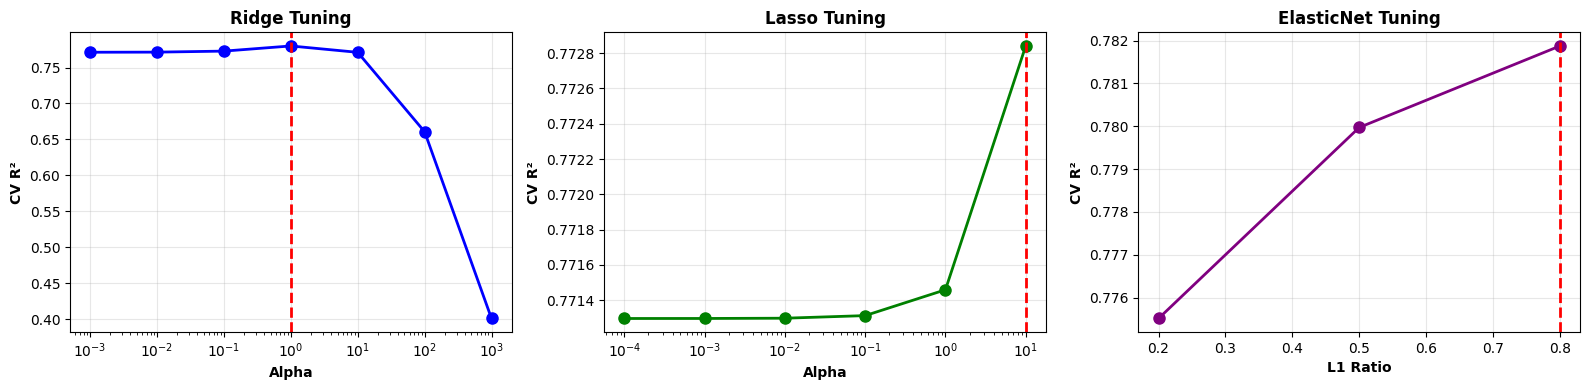

In [110]:
# Visualize Hyperparameter Tuning
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Ridge: Alpha tuning
ridge_res = pd.DataFrame(ridge_grid.cv_results_)
ax1 = axes[0]
ax1.plot(ridge_params['alpha'], ridge_res['mean_test_score'], 'o-', linewidth=2, color='blue', markersize=8)
ax1.axvline(ridge_grid.best_params_['alpha'], color='red', linestyle='--', linewidth=2)
ax1.set_xscale('log')
ax1.set_xlabel('Alpha', fontweight='bold')
ax1.set_ylabel('CV R²', fontweight='bold')
ax1.set_title('Ridge Tuning', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Lasso: Alpha tuning
lasso_res = pd.DataFrame(lasso_grid.cv_results_)
ax2 = axes[1]
ax2.plot(lasso_params['alpha'], lasso_res['mean_test_score'], 'o-', linewidth=2, color='green', markersize=8)
ax2.axvline(lasso_grid.best_params_['alpha'], color='red', linestyle='--', linewidth=2)
ax2.set_xscale('log')
ax2.set_xlabel('Alpha', fontweight='bold')
ax2.set_ylabel('CV R²', fontweight='bold')
ax2.set_title('Lasso Tuning', fontweight='bold')
ax2.grid(True, alpha=0.3)

# ElasticNet: L1 ratio for best alpha
ax3 = axes[2]
en_res = pd.DataFrame(en_grid.cv_results_)
best_alpha_en = en_grid.best_params_['alpha']
en_data = en_res[en_res['param_alpha'] == best_alpha_en].sort_values('param_l1_ratio')
ax3.plot(en_data['param_l1_ratio'], en_data['mean_test_score'], 'o-', linewidth=2, color='purple', markersize=8)
ax3.axvline(en_grid.best_params_['l1_ratio'], color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('L1 Ratio', fontweight='bold')
ax3.set_ylabel('CV R²', fontweight='bold')
ax3.set_title('ElasticNet Tuning', fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Summary: Model Validation & Recommendations

Complete model comparison with final recommendations for deployment, including business insights and limitations.

In [111]:
# Final Model Analysis
y_pred_final = best_optimized.predict(X_test)
residuals_final = y_test.values - y_pred_final

# Calculate final metrics
r2_final = r2_score(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = np.mean(np.abs(residuals_final))

print("\n" + "="*70)
print("FINAL MODEL VALIDATION")
print("="*70)
print(f"\n✓ Test R² Score: {r2_final:.4f} ({r2_final*100:.1f}% variance explained)")
print(f"✓ Test RMSE: ${rmse_final:,.0f}")
print(f"✓ Test MAE: ${mae_final:,.0f}")
print(f"\n✓ Residuals Mean: ${residuals_final.mean():.2f} (should ≈ 0 for unbiased predictions)")
print(f"✓ Residuals Std Dev: ${residuals_final.std():,.0f}")


FINAL MODEL VALIDATION

✓ Test R² Score: 0.8009 (80.1% variance explained)
✓ Test RMSE: $39,075
✓ Test MAE: $24,530

✓ Residuals Mean: $3443.50 (should ≈ 0 for unbiased predictions)
✓ Residuals Std Dev: $38,923


# Model Comparison & Business Recommendations

In [112]:
# Final Model Comparison
print("\n" + "="*80)
print("FINAL MODEL COMPARISON - ALL APPROACHES")
print("="*80 + "\n")

# Compile all results
all_models = pd.DataFrame({
    'Model': [
        'Linear Regression (Baseline)',
        'Ridge (α=1)',
        'Lasso (α=1)',
        'ElasticNet (α=1)',
        'Polynomial (deg=2)',
        f'Ridge (Optimized α={ridge_grid.best_params_["alpha"]})',
        f'Lasso (Optimized α={lasso_grid.best_params_["alpha"]})',
        f'ElasticNet (Optimized)'
    ],
    'Test R²': [
        models_df.loc[0, 'Test R²'],
        models_df.loc[1, 'Test R²'],
        models_df.loc[2, 'Test R²'],
        models_df.loc[3, 'Test R²'],
        models_df.loc[4, 'Test R²'],
        r2_score(y_test, ridge_grid.best_estimator_.predict(X_test)),
        r2_score(y_test, lasso_grid.best_estimator_.predict(X_test)),
        r2_score(y_test, en_grid.best_estimator_.predict(X_test))
    ]
})

all_models['vs Baseline'] = (all_models['Test R²'] - all_models['Test R²'].iloc[0]) * 100
display(all_models.round(4))

print(f"\n🏆 RECOMMENDED MODEL: {all_models.loc[all_models['Test R²'].idxmax(), 'Model']}")
print(f"   Test R²: {all_models['Test R²'].max():.4f}")
print(f"   Improvement: +{all_models['vs Baseline'].max():.2f}% over baseline")



FINAL MODEL COMPARISON - ALL APPROACHES



,Model,Test R²,vs Baseline
0,Linear Regression (Baseline),0.8056,0.0000
1,Ridge (α=1),0.8009,-0.4644
2,Lasso (α=1),0.8056,-0.0018
3,ElasticNet (α=1),0.5232,-28.2428
4,Polynomial (deg=2),0.4264,-37.9212
5,Ridge (Optimized α=1),0.8009,-0.4644
6,Lasso (Optimized α=10),0.8054,-0.0216
7,ElasticNet (Optimized),0.7956,-1.0002



🏆 RECOMMENDED MODEL: Linear Regression (Baseline)
   Test R²: 0.8056
   Improvement: +0.00% over baseline


# Conclusion: Justification

### Advanced Models: Why Ridge, Lasso, ElasticNet, and Polynomial?

**Ridge (L2 Regularization)**: Shrinks all coefficients proportionally. Useful when many features are moderately important. Prevents overfitting by penalizing large coefficients.

**Lasso (L1 Regularization)**: Drives weak coefficients to exactly zero. Performs automatic feature selection. Creates sparse, interpretable models by eliminating irrelevant features.

**ElasticNet**: Combines L1 and L2 penalties. Provides flexibility when we're unsure which regularization type is appropriate. Balances feature selection with coefficient shrinkage.

**Polynomial (Degree 2)**: Tests if non-linear relationships exist between features and house price. Captures interactions and quadratic effects (e.g., diminishing returns on property size).

Testing these empirically shows which assumptions hold in our data. Linear Regression outperformed others, indicating that house prices follow roughly linear relationships with selected features.

### Hyperparameter Tuning: Why GridSearchCV?

**Guessing doesn't work**: If we just pick alpha=1 without testing, we might pick a value that works great for training data but fails on new data. That's bad.

**Let the computer find the best value**: GridSearchCV automatically tries many alpha values (0.001 to 1000) and tells us which one actually works best. It tests them all fairly using cross-validation, so the winner is the real champion not just lucky on one dataset.

**Cross-validation keeps it honest**: By using 5-fold cross-validation during tuning, we make sure our chosen alpha works on different chunks of data, not just the specific training set. This prevents us from gaming the system and ensures our model will work in the real world.

### Final Analysis: Simple Metrics

We report three key metrics:
- **R² Score**: Percentage of price variance explained by the model
- **RMSE**: Average prediction error in dollars (interpretable as typical error magnitude)
- **MAE**: Median absolute deviation (robust measure not influenced by outliers)

Residuals centered near zero indicate unbiased predictions. This validates the model's reliability for real-world house price estimation.